In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.22513827 0.98191029 0.86787335 ... 0.65245846 0.74387743 0.85008286]
 [0.07997859 0.34881586 0.30830514 ... 0.2317807  0.26425657 0.30198521]
 [0.21773939 0.94964104 0.83935178 ... 0.63101623 0.71943083 0.82214596]
 ...
 [0.10634924 0.46382792 0.40995994 ... 0.30820377 0.35138762 0.4015562 ]
 [0.06273097 0.27359267 0.24181821 ... 0.1817965  0.20726885 0.2368612 ]
 [0.20955629 0.91395156 0.8078072  ... 0.60730134 0.69239313 0.79124801]]

Noisy Matrix (with Homoscedastic Noise):
[[ 0.13217624  1.08639485  0.79914742 ...  0.7186244   0.75760603
   0.73409432]
 [ 0.16503443  0.24736671  0.44820262 ...  0.2631446   0.22379082
   0.18817466]
 [ 0.23389239  1.01267687  0.81543406 ...  0.58356337  0.50307324
   0.89616715]
 ...
 [-0.06215303  0.34020387  0.64160785 ...  0.3484576   0.40795102
   0.32659459]
 [-0.10535132  0.23953438  0.33213204 ...  0.23145006  0.21151262
   0.13167289]
 [ 0.18523935  1.06420154  0.86243558 ...  0.61972876  0.8108287
   0.648

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix) 

mycebmf.initialise_factors()

In [5]:
 
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([ 0.1292,  0.2949,  0.0236,  0.3072, -0.0343, -0.2370, -0.1570,  0.0538,
        -0.2080,  0.1566, -0.2285, -0.2616, -0.0565, -0.3064, -0.2781, -0.1804,
        -0.1199,  0.0820, -0.0668, -0.0763,  0.0428,  0.2872,  0.0033,  0.2117,
         0.1392, -0.0020,  0.0692,  0.0012,  0.0065,  0.0941, -0.0829,  0.0475,
        -0.1162,  0.0947,  0.1168, -0.0577,  0.1232,  0.0796, -0.0194, -0.1228,
         0.3441, -0.3966,  0.0778, -0.1036,  0.1594, -0.1566,  0.0538,  0.3218,
         0.0818,  0.0405], dtype=torch.float64)
tensor([-0.1094, -0.2167,  0.2177, -0.3874,  0.3570, -0.0492,  0.0028,  0.0286,
         0.1375,  0.3831,  0.1805,  0.0071, -0.0999,  0.0610, -0.0063, -0.0496,
         0.0579, -0.1327,  0.0297, -0.1451,  0.0884, -0.2582, -0.1782, -0.1811,
        -0.0832, -0.0395, -0.0842,  0.0399,  0.0510,  0.1496,  0.0570,  0.0978,
         0.0874, -0.0632,  0.1025, -0.2440, -0.0827,  0.2608, -0.0173, -0.0681],
       dtype=torch.float64)


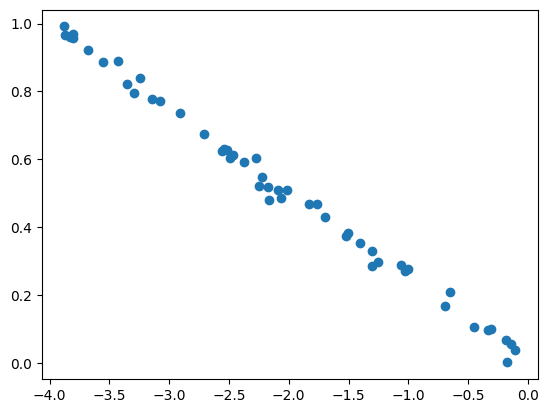

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.1882, 1.0083, 0.8478,  ..., 0.6368, 0.7401, 0.8000],
        [0.0555, 0.3265, 0.3395,  ..., 0.2730, 0.2669, 0.2845],
        [0.1948, 1.0038, 0.8120,  ..., 0.6182, 0.7253, 0.7847],
        ...,
        [0.0729, 0.4160, 0.4624,  ..., 0.3333, 0.3477, 0.3662],
        [0.0472, 0.2487, 0.2321,  ..., 0.1645, 0.1908, 0.2072],
        [0.1873, 0.9487, 0.8156,  ..., 0.5974, 0.7026, 0.7631]],
       dtype=torch.float64)

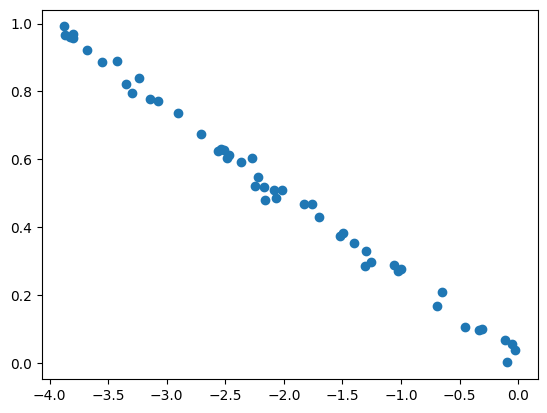

In [8]:
plt.scatter( mycebmf.L[:,0],u)

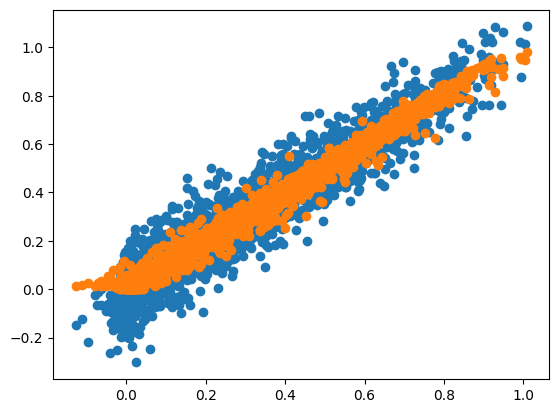

In [9]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf=  cEBMF(data= noisy_matrix) 
mycebmf.initialise_factors()

In [11]:
mycebmf.fit()

CEBMFResult(L=tensor([[-3.8796],
        [-1.4059],
        [-3.8038],
        [-0.6952],
        [-0.2987],
        [-2.0160],
        [-1.2559],
        [-1.3049],
        [-3.3568],
        [-2.2732],
        [-2.5622],
        [-1.5244],
        [-2.9083],
        [-0.0404],
        [-3.4309],
        [-1.3057],
        [-3.2428],
        [-0.3311],
        [-2.2197],
        [-2.7043],
        [-3.2982],
        [-1.0648],
        [-3.8059],
        [-0.4507],
        [-2.4685],
        [-3.8323],
        [-2.1628],
        [-0.0227],
        [-2.5444],
        [-0.6524],
        [-2.4908],
        [-1.0296],
        [-2.5172],
        [-3.5586],
        [-3.0813],
        [-1.5026],
        [-2.0916],
        [-3.1475],
        [-0.0832],
        [-2.0665],
        [-2.2518],
        [-2.1709],
        [-1.7018],
        [-2.3714],
        [-3.8768],
        [-0.0730],
        [-1.7607],
        [-1.8287],
        [-0.9997],
        [-3.6833]], dtype=torch.float64), F=tensor([[-0

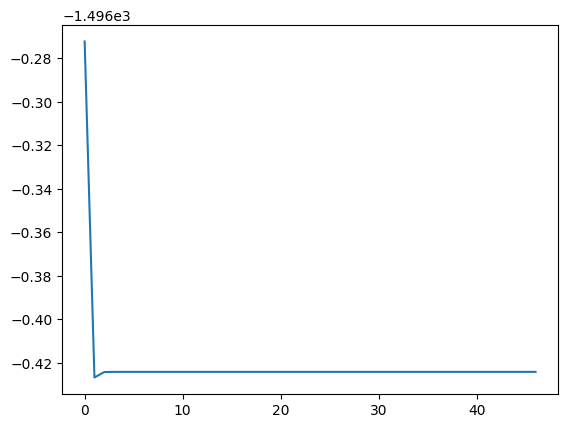

In [12]:
plt.plot(mycebmf.obj)

tensor(0.0045, dtype=torch.float64)

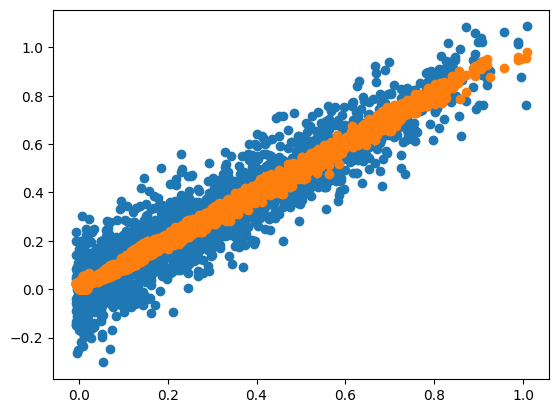

In [13]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [14]:
results =[]
tau_est =[] 
    # Parameters
n, p = 50, 40
noise_std = 0.1

for i in range(100):
    torch.manual_seed(i)              # so you can match flashier seeds 1..100

    u = torch.rand(n, dtype=torch.float64, device=device)
    v = torch.rand(p, dtype=torch.float64, device=device)
    rank_1 = torch.outer(u, v)
    Y      = rank_1 + noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    m = cEBMF(data=Y, K=1)             # prior_L = prior_F = "norm" by default
    m.initialise_factors()              # SVD init
    m.fit(50)
    m._update_fitted_value()

    rmse = torch.sqrt(torch.mean((m.Y_fit - rank_1) ** 2)).item()
    var_hat = (1.0 / m.tau).item()
    results.append(rmse)
    tau_est.append(var_hat)

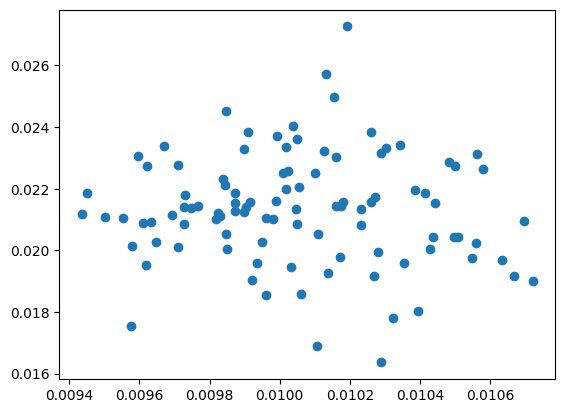

In [15]:
plt.scatter( tau_est, results)

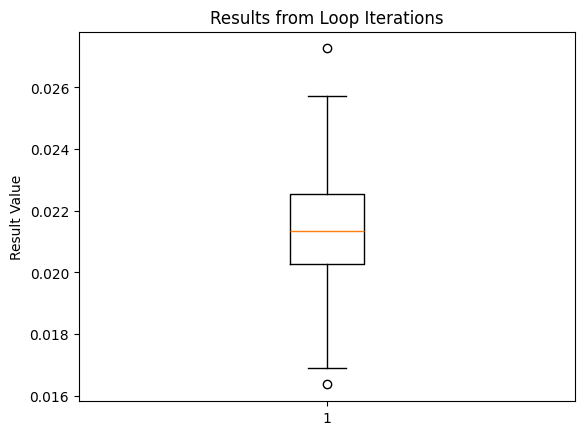

In [16]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [17]:
np.quantile(results,q=0.5)

np.float64(0.02133678878980924)

In [18]:
res= np.asarray(results)
np.mean(res )

np.float64(0.021335144254991736)

In [19]:
np.sqrt(np.var(res ))

np.float64(0.001800007536041549)

In [20]:
# 0.002615278465597284